<a href="https://colab.research.google.com/github/padelacruz85/DAF2026/blob/main/%5BDESCRIPTIVE_ANALYSIS%5D_MotorPH_Products_List_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/padelacruz85/DAF2026/blob/main/Milestone_1/%5BDESCRIPTIVE_ANALYSIS%5D_MotorPH_Products_List_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MotorPH Products List 2025 – Descriptive Analysis**

Converted from `[DATA_PREPROCESSING]_MotorPH_Products_List_2025.ipynb`: the cleaning pipeline now feeds a descriptive analysis of the MotorPH product list.

In [25]:
# Connecting to google drive (Colab). Skipped automatically outside Colab.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
#Import libraries
import os
import numpy as np                 #arithmetic and statistical computations
import pandas as pd                #data wrangling and manipulation
import matplotlib.pyplot as plt    #Basic Data Viz
import seaborn as sns              #Intermediate Statistical Data Viz
from scipy import stats            #intermediate statistical computation

sns.set_theme(style="whitegrid")
pd.options.display.float_format = "{:,.2f}".format

In [27]:
#Load Data Set
DRIVE_DIR = "/content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 05/Dataset Preprocessing/"
GITHUB    = "https://raw.githubusercontent.com/padelacruz85/DAF2026/main/Raw_Data/"
PROCESSED = "[CLEANED_DATA]_MotorPH_Products_List_2025.csv"
RAW_FILE  = "[RAW_DATA]_MotorPH_Products_List_2025.csv"
SALES     = "[RAW_DATA]_MotorPH_Sales Data-3rd Quarter-Year 2025.csv"

def locate(fname):
    """Google Drive first, then local folders, then the GitHub repo (raw files only)."""
    for p in [DRIVE_DIR + fname, fname, "Raw_Data/" + fname, "../Raw_Data/" + fname]:
        if os.path.exists(p):
            return p
    return GITHUB + fname.replace("[", "%5B").replace("]", "%5D").replace(" ", "%20")

PRICE, CC = "Unit Price (PHP)", "Engine Displacement (cc)"


# **0. PREPARE THE DATA**

Uses the cleaned file produced by the preprocessing notebook. If it is not found, the same cleaning steps are re-applied to the raw file, so this notebook always runs on clean data.

In [28]:
def preprocess(raw, sales):
    """Same cleaning steps as the [DATA_PREPROCESSING] notebook."""
    d = raw.drop_duplicates().drop_duplicates(subset="EntrName").copy()
    for col in ["EntrName", "EntrDetails"]:
        d[col] = d[col].astype("string").str.strip().str.replace(r"\s+", " ", regex=True)
    # Price outlier: SYM Husky 150 listed at 7,290,011; Q3 sales show 72,900 (data-entry error)
    husky = sales.loc[sales["product"].str.strip() == "SYM Husky 150", "unitprice"].unique()
    d.loc[d["EntrName"].eq("SYM Husky 150"), "UnitPrice"] = int(husky[0])
    det = d["EntrDetails"].str.extract(
        r"^(?P<type>[^/]+?)\s*/\s*(?P<engine>[^,]+),\s*(?P<cooling>[^,]+),\s*(?P<cc>\d+)\s*cc,\s*(?P<trans>.+)$")
    hy = lambda s: "-".join(w.capitalize() for w in s.split("-"))
    return pd.DataFrame({
        "Product ID Number": np.arange(1, len(d) + 1),
        "Product Name":   d["EntrName"].astype("string").values,
        "Product Type":   det["type"].str.strip().str.title().values,
        "Engine Type":    det["engine"].str.strip().str.title().str.replace("Parallel-Twin", "Parallel Twin").values,
        "Cooling System": det["cooling"].str.strip().apply(lambda s: "/".join(hy(x) for x in s.split("/"))).values,
        CC:               det["cc"].astype("int64").values,
        "Transmission":   det["trans"].str.strip().str.replace("-speed", "-Speed", regex=False).values,
        "Manufacturing Year": d["Manufacturing Date"].astype("int64").values,
        "Acquisition Year":   d["Acquisiton"].astype("int64").values,
        PRICE:            d["UnitPrice"].astype("float64").round(2).values,
    })

proc_path = next((p for p in [DRIVE_DIR + PROCESSED, PROCESSED, "../" + PROCESSED, "Milestone_1/" + PROCESSED] if os.path.exists(p)), None)
if proc_path:
    df = pd.read_csv(proc_path)
    print("Loaded cleaned data from:", proc_path)
else:
    df = preprocess(pd.read_csv(locate(RAW_FILE)), pd.read_csv(locate(SALES)))
    print("Cleaned file not found - rebuilt from raw data.")

df["Brand"] = df["Product Name"].str.split().str[0]        # derived: manufacturer (first word of the name)
df["Years to Acquire"] = df["Acquisition Year"] - df["Manufacturing Year"]
df.head(10)


Loaded cleaned data from: /content/drive/MyDrive/4thYR_Term1/MO-IT106 - Data Analytics Fundamentals/Week 05/Dataset Preprocessing/[CLEANED_DATA]_MotorPH_Products_List_2025.csv


,Product ID Number,Product Name,Product Type,Engine Type,Cooling System,Engine Displacement (cc),Transmission,Manufacturing Year,Acquisition Year,Unit Price (PHP),Brand,Years to Acquire
0,1,Honda CBR500R,Sport,Parallel Twin,Liquid-Cooled,471,6-Speed,2021,2023,"389,000.00",Honda,2
1,2,Yamaha MT-15,Naked Bike,Single Cylinder,Liquid-Cooled,155,6-Speed,2022,2023,"178,000.00",Yamaha,1
2,3,Kawasaki Ninja 400,Sport,Parallel Twin,Liquid-Cooled,399,6-Speed,2023,2024,"340,000.00",Kawasaki,1
3,4,Suzuki Raider R150 Fi,Underbone,Single Cylinder,Liquid-Cooled,150,6-Speed,2020,2021,"119,900.00",Suzuki,1
4,5,Royal Enfield Classic 350,Classic,Single Cylinder,Air-Cooled,349,5-Speed,2022,2023,"250,000.00",Royal,1
5,6,CFMoto 300NK,Naked Bike,Single Cylinder,Liquid-Cooled,292,6-Speed,2021,2022,"165,000.00",CFMoto,1
6,7,Bristol Veloce 500,Cafe Racer,Twin Cylinder,Air-Cooled,471,6-Speed,2022,2023,"328,000.00",Bristol,1
7,8,KTM Duke 200,Naked Bike,Single Cylinder,Liquid-Cooled,199,6-Speed,2023,2024,"178,000.00",KTM,1
8,9,Yamaha XSR155,Retro,Single Cylinder,Liquid-Cooled,155,6-Speed,2022,2023,"182,000.00",Yamaha,1
9,10,Bajaj Dominar 400,Sport Touring,Single Cylinder,Liquid-Cooled,373,6-Speed,2021,2022,"199,900.00",Bajaj,1


# **1. DATA SET OVERVIEW**

In [29]:
print("Rows, columns:", df.shape)
df.info()

Rows, columns: (50, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Product ID Number         50 non-null     int64  
 1   Product Name              50 non-null     object 
 2   Product Type              50 non-null     object 
 3   Engine Type               50 non-null     object 
 4   Cooling System            50 non-null     object 
 5   Engine Displacement (cc)  50 non-null     int64  
 6   Transmission              50 non-null     object 
 7   Manufacturing Year        50 non-null     int64  
 8   Acquisition Year          50 non-null     int64  
 9   Unit Price (PHP)          50 non-null     float64
 10  Brand                     50 non-null     object 
 11  Years to Acquire          50 non-null     int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 4.8+ KB


In [30]:
# Quick quality confirmation
print("Missing values :", df.isna().sum().sum())
print("Duplicate rows :", df.duplicated().sum())
print("Unique brands  :", df["Brand"].nunique())
print("Product types  :", df["Product Type"].nunique())

Missing values : 0
Duplicate rows : 0
Unique brands  : 23
Product types  : 17


# **2. NUMERICAL VARIABLES**

In [31]:
num_cols = [PRICE, CC, "Manufacturing Year", "Acquisition Year"]
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc["range"] = desc["max"] - desc["min"]
desc["IQR"] = desc["75%"] - desc["25%"]
desc["CV (%)"] = desc["std"] / desc["mean"] * 100
desc["skewness"] = df[num_cols].skew()
desc["kurtosis"] = df[num_cols].kurt()
desc[["count","mean","median","std","min","25%","75%","max","range","IQR","CV (%)","skewness","kurtosis"]]

,count,mean,median,std,min,25%,75%,max,range,IQR,CV (%),skewness,kurtosis
Unit Price (PHP),50.00,"257,872.00","204,950.00","183,425.06","48,000.00","126,425.00","330,250.00","995,000.00","947,000.00","203,825.00",71.13,1.83,4.64
Engine Displacement (cc),50.00,332.08,241.00,251.09,124.00,155.00,392.50,"1,170.00","1,046.00",237.50,75.61,1.74,2.73
Manufacturing Year,50.00,"2,022.06","2,022.00",1.00,"2,020.00","2,021.25","2,023.00","2,023.00",3.00,1.75,0.05,-0.77,-0.48
Acquisition Year,50.00,"2,023.08","2,023.00",0.99,"2,021.00","2,023.00","2,024.00","2,024.00",3.00,1.00,0.05,-0.83,-0.31


In [32]:
# Mode of each numerical field
for col in num_cols:
    print(f"{col:28s} mode(s): {df[col].mode().tolist()}")

Unit Price (PHP)             mode(s): [80900.0, 165000.0, 178000.0, 398000.0]
Engine Displacement (cc)     mode(s): [155]
Manufacturing Year           mode(s): [2023]
Acquisition Year             mode(s): [2024]


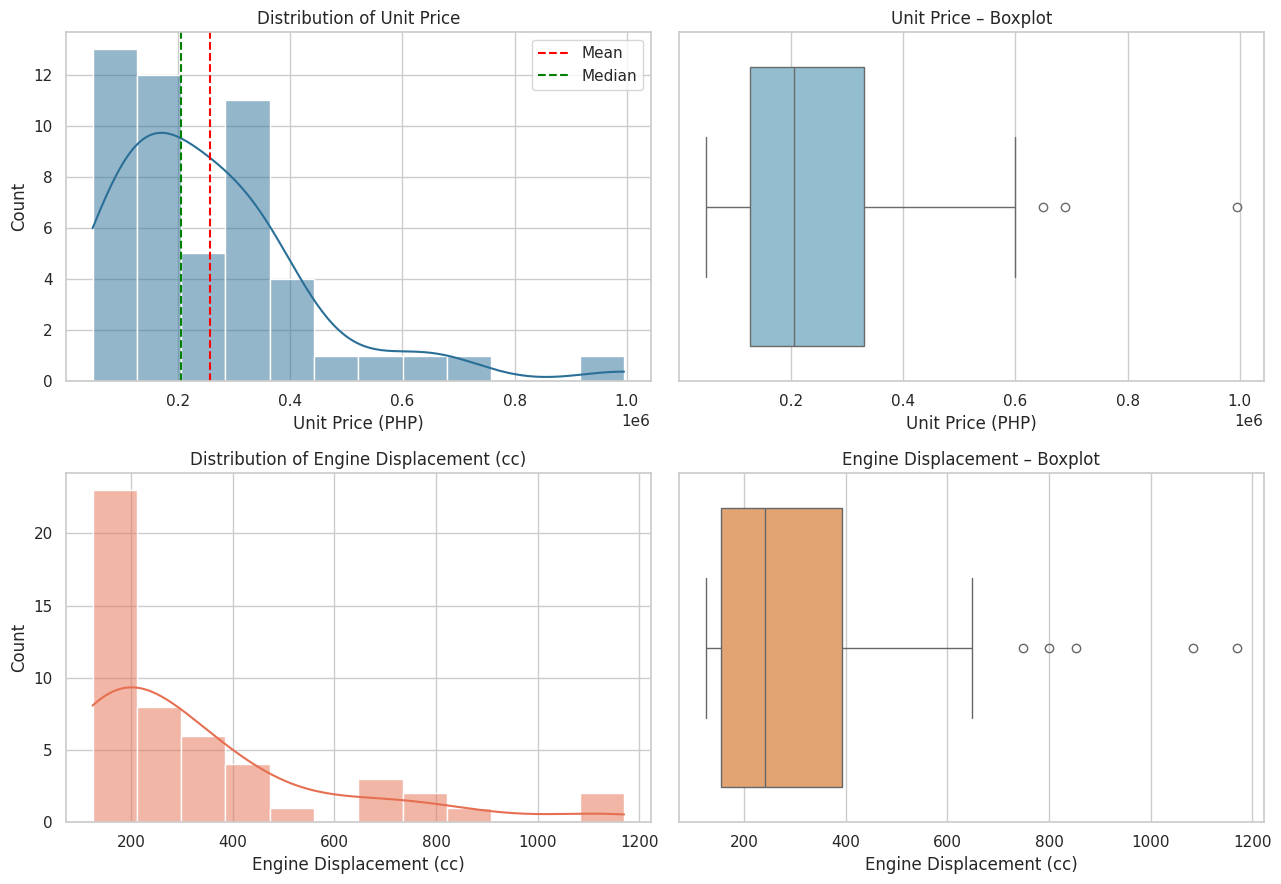

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(df[PRICE], bins=12, kde=True, ax=axes[0,0], color="#2a6f97")
axes[0,0].axvline(df[PRICE].mean(),   color="red",   ls="--", label="Mean")
axes[0,0].axvline(df[PRICE].median(), color="green", ls="--", label="Median")
axes[0,0].set_title("Distribution of Unit Price"); axes[0,0].legend()
sns.boxplot(x=df[PRICE], ax=axes[0,1], color="#89c2d9"); axes[0,1].set_title("Unit Price – Boxplot")
sns.histplot(df[CC], bins=12, kde=True, ax=axes[1,0], color="#e76f51"); axes[1,0].set_title("Distribution of Engine Displacement (cc)")
sns.boxplot(x=df[CC], ax=axes[1,1], color="#f4a261"); axes[1,1].set_title("Engine Displacement – Boxplot")
plt.tight_layout(); plt.show()

### Interpretation – numerical variables
- **Unit price** averages about **₱257,872** but the median is only **₱204,950**. The mean sits well above the median and the skewness is positive (**1.83**), so the distribution is right-skewed: most models are mid-priced and a few premium bikes pull the average up.
- Prices are widely spread (std ≈ ₱183,425, **CV ≈ 71%**), ranging from **₱48,000** (Rusi Flash 125) to **₱995,000** (BMW R nineT). The middle 50% of products falls between ₱126,425 and ₱330,250.
- **Engine displacement** ranges from 124 cc to 1,170 cc with a median of **241 cc** (mean 332 cc), also right-skewed: the catalogue is dominated by small-to-mid displacement motorcycles.
- **Manufacturing years** span 2020–2023 and **acquisition years** 2021–2024, with the median acquisition in 2023.

# **3. CATEGORICAL VARIABLES**

In [34]:
def freq(col):
    t = df[col].value_counts().to_frame("Count")
    t["Percent (%)"] = (t["Count"] / len(df) * 100).round(1)
    return t

for col in ["Product Type", "Engine Type", "Cooling System", "Transmission", "Brand"]:
    print(f"--- {col} ---")
    display(freq(col).head(10)) if "display" in globals() else print(freq(col).head(10))
    print()

--- Product Type ---
              Count  Percent (%)
Product Type                    
Scooter          12        24.00
Naked Bike        7        14.00
Sport             4         8.00
Adventure         4         8.00
Cruiser           4         8.00
Dual-Sport        3         6.00
Underbone         3         6.00
Cafe Racer        2         4.00
Commuter          2         4.00
Heritage          2         4.00

--- Engine Type ---
                 Count  Percent (%)
Engine Type                        
Single Cylinder     37        74.00
Parallel Twin        9        18.00
V-Twin               2         4.00
Twin Cylinder        1         2.00
Flat Twin            1         2.00

--- Cooling System ---
                Count  Percent (%)
Cooling System                    
Liquid-Cooled      34        68.00
Air-Cooled         13        26.00
Oil-Cooled          2         4.00
Air/Oil-Cooled      1         2.00

--- Transmission ---
              Count  Percent (%)
Transmission         

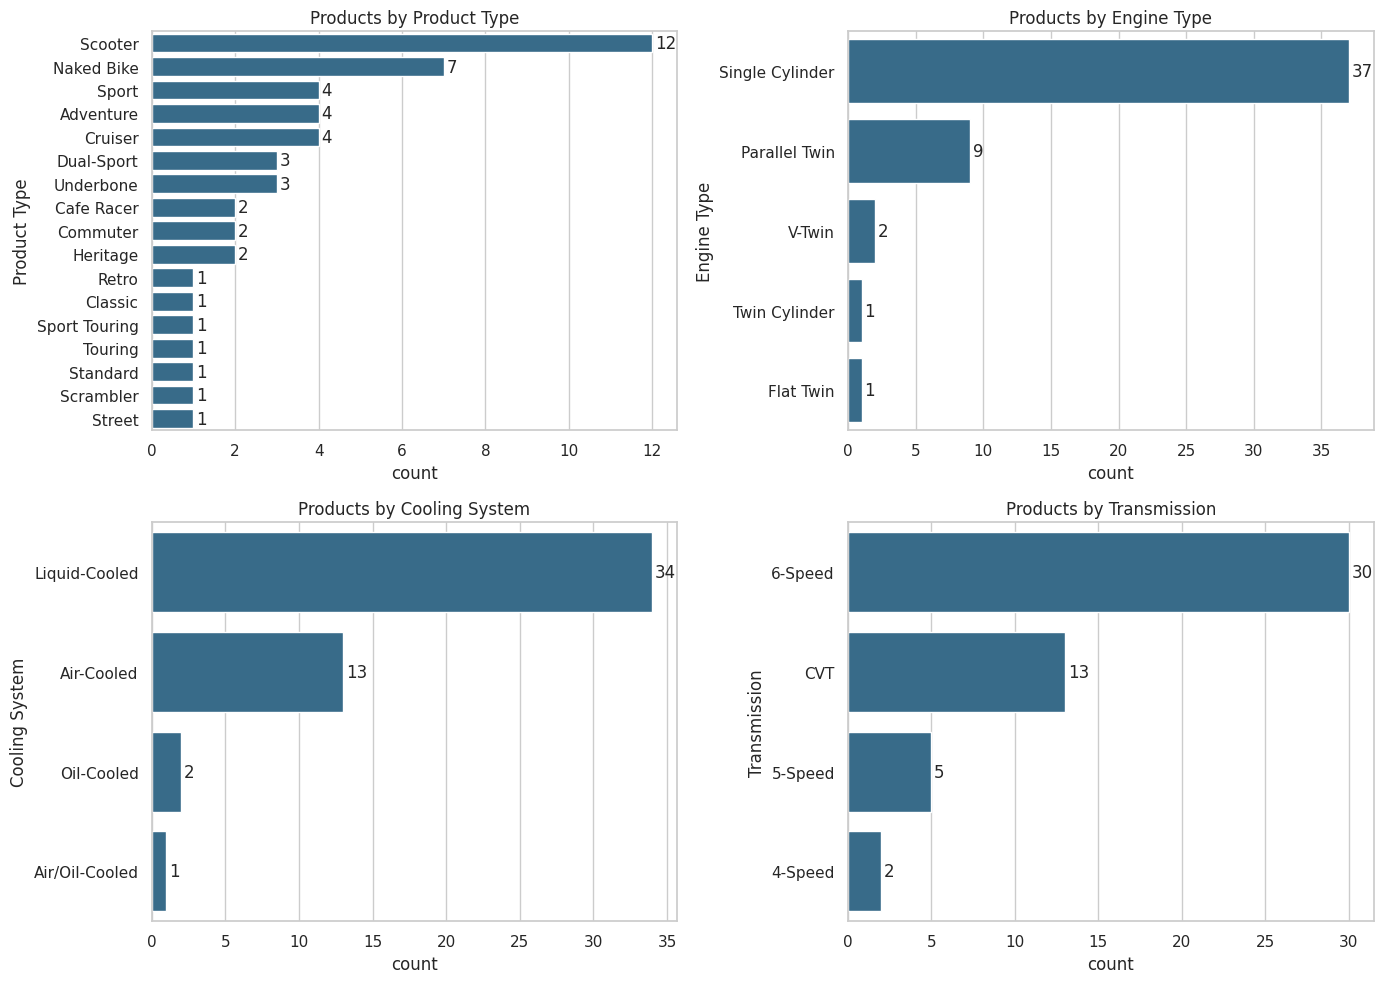

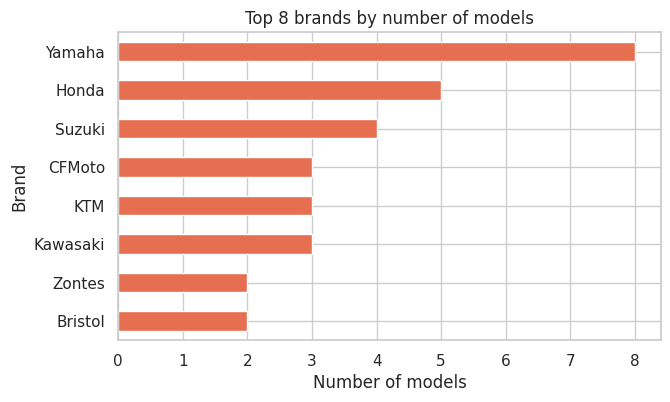

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, ["Product Type", "Engine Type", "Cooling System", "Transmission"]):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=ax, color="#2a6f97")
    ax.set_title(f"Products by {col}")
    for cont in ax.containers: ax.bar_label(cont, padding=2)
plt.tight_layout(); plt.show()

top = df["Brand"].value_counts().head(8)
top.sort_values().plot(kind="barh", figsize=(7,4), color="#e76f51", title="Top 8 brands by number of models")
plt.xlabel("Number of models"); plt.show()

### Interpretation – categorical variables
- **Product type:** Scooters are the largest group (**12 of 50, 24%**), followed by Naked Bikes (7). Sport, Adventure and Cruiser have 4 each; the other 12 types have only 1–3 models each.
- **Engine type:** **Single-cylinder** engines dominate (**37 models, 74%**); Parallel Twins are next (9). V-Twin (2), Flat Twin (1) and Twin Cylinder (1) are niche.
- **Cooling:** **Liquid-cooled** is the majority (**34, 68%**), then air-cooled (13); oil-cooled and air/oil-cooled are rare.
- **Transmission:** **6-speed** manuals lead (**30, 60%**), followed by CVT (13, mostly scooters), 5-speed (5) and 4-speed (2).
- **Brands:** The 50 models come from **23 brands**. Yamaha (8) has the most models, then Honda (5) and Suzuki (4).

# **4. TIME PERIOD ANALYSIS**

In [36]:
yr = df.groupby("Manufacturing Year")[PRICE].agg(["count","mean","median","min","max"])
display(yr) if "display" in globals() else print(yr)
print(df["Years to Acquire"].value_counts().rename("Count").to_frame())

                    count       mean     median       min        max
Manufacturing Year                                                  
2020                    5 208,960.00 119,900.00 48,000.00 499,000.00
2021                    8 164,200.00 145,000.00 67,900.00 389,000.00
2022                   16 236,793.75 190,500.00 72,900.00 689,000.00
2023                   21 321,261.90 289,000.00 79,900.00 995,000.00
                  Count
Years to Acquire       
1                    49
2                     1


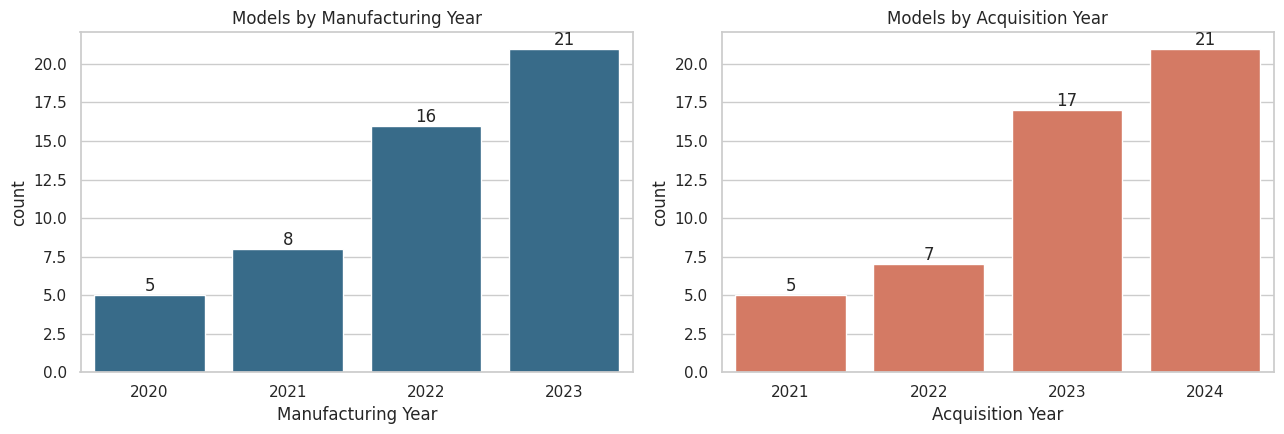

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.countplot(x=df["Manufacturing Year"], ax=axes[0], color="#2a6f97"); axes[0].set_title("Models by Manufacturing Year")
sns.countplot(x=df["Acquisition Year"],  ax=axes[1], color="#e76f51"); axes[1].set_title("Models by Acquisition Year")
for ax in axes:
    for cont in ax.containers: ax.bar_label(cont)
plt.tight_layout(); plt.show()

### Interpretation – time period
- The product line is **recent**: 21 of 50 models (42%) were manufactured in 2023 and 37 (74%) in 2022–2023. Only 5 date from 2020.
- Acquisition follows manufacturing closely: **49 of 50 models were acquired 1 year after manufacture**; the exception is the Honda CBR500R (made 2021, acquired 2023, a 2-year gap).
- Newer model years are priced higher on average (₱164,200 for 2021 versus ₱321,262 for 2023), but the correlation with price is weak (r ≈ 0.29), so model year is not a strong price driver on its own.

# **5. PRICE BY CATEGORY**

In [38]:
for col in ["Product Type", "Engine Type", "Cooling System", "Transmission"]:
    t = (df.groupby(col)[PRICE].agg(["count","mean","median","min","max"])
           .sort_values("mean", ascending=False))
    print(f"--- Unit price by {col} ---")
    display(t) if "display" in globals() else print(t)
    print()

--- Unit price by Product Type ---
               count       mean     median        min        max
Product Type                                                    
Heritage           2 842,000.00 842,000.00 689,000.00 995,000.00
Cruiser            4 474,000.00 448,500.00 349,000.00 650,000.00
Touring            1 345,000.00 345,000.00 345,000.00 345,000.00
Cafe Racer         2 298,500.00 298,500.00 269,000.00 328,000.00
Scrambler          1 295,000.00 295,000.00 295,000.00 295,000.00
Sport              4 273,000.00 269,000.00 165,000.00 389,000.00
Dual-Sport         3 260,966.67 284,900.00 199,000.00 299,000.00
Adventure          4 253,975.00 284,000.00  78,900.00 369,000.00
Classic            1 250,000.00 250,000.00 250,000.00 250,000.00
Naked Bike         7 243,571.43 178,000.00 125,000.00 599,000.00
Sport Touring      1 199,900.00 199,900.00 199,900.00 199,900.00
Scooter           12 187,125.00 158,400.00  79,900.00 398,000.00
Retro              1 182,000.00 182,000.00 182,000.00 1

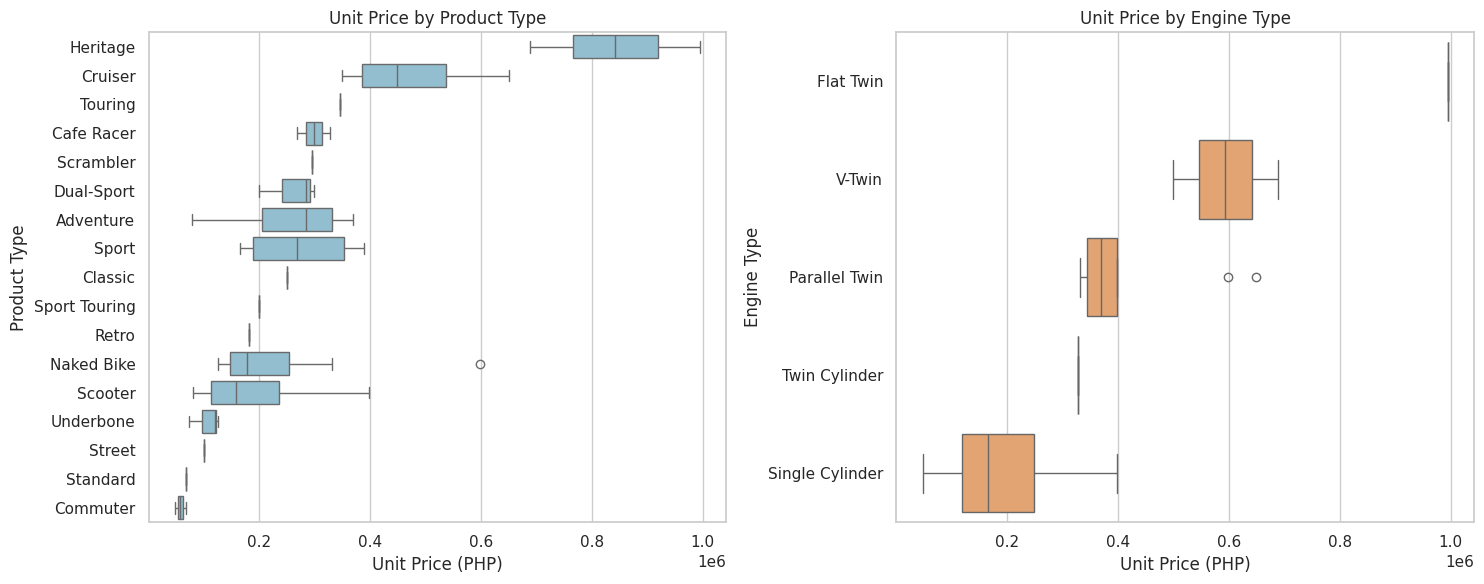

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
order = df.groupby("Product Type")[PRICE].median().sort_values(ascending=False).index
sns.boxplot(data=df, y="Product Type", x=PRICE, order=order, ax=axes[0], color="#89c2d9")
axes[0].set_title("Unit Price by Product Type")
order = df.groupby("Engine Type")[PRICE].median().sort_values(ascending=False).index
sns.boxplot(data=df, y="Engine Type", x=PRICE, order=order, ax=axes[1], color="#f4a261")
axes[1].set_title("Unit Price by Engine Type")
plt.tight_layout(); plt.show()

### Interpretation – price by category
- **Heritage** (avg ₱842,000) and **Cruiser** (₱474,000) are the most expensive types. **Commuter** (₱57,950), **Standard** (₱68,900) and **Street** (₱99,900) are the cheapest.
- **Scooters**, the largest group, are mid-to-low priced (median ₱158,400), though they range from ₱79,900 (Suzuki Avenis 125) to ₱398,000 (Vespa GTS Super 300).
- Price rises with engine complexity: single-cylinder bikes average **₱178,719**, parallel twins **₱418,889** and V-twins **₱594,000**. The single flat-twin (BMW R nineT) is the highest-priced item at ₱995,000.
- Liquid-cooled models average ₱270,509 and 6-speed models ₱320,417, compared with ₱178,338 for CVT and ₱57,950 for 4-speed. Type groups with only 1–2 models give weak averages, so read them as indications only.

# **6. RELATIONSHIPS BETWEEN NUMERICAL VARIABLES**

In [40]:
corr = df[num_cols].corr()
display(corr) if "display" in globals() else print(corr)
r, p = stats.pearsonr(df[CC], df[PRICE]); rho, p2 = stats.spearmanr(df[CC], df[PRICE])
print(f"\nPrice vs Displacement: Pearson r = {r:.2f} (p = {p:.1e}); Spearman rho = {rho:.2f} (p = {p2:.1e})")

                          Unit Price (PHP)  Engine Displacement (cc)  \
Unit Price (PHP)                      1.00                      0.93   
Engine Displacement (cc)              0.93                      1.00   
Manufacturing Year                    0.29                      0.21   
Acquisition Year                      0.30                      0.22   

                          Manufacturing Year  Acquisition Year  
Unit Price (PHP)                        0.29              0.30  
Engine Displacement (cc)                0.21              0.22  
Manufacturing Year                      1.00              0.99  
Acquisition Year                        0.99              1.00  

Price vs Displacement: Pearson r = 0.93 (p = 3.4e-22); Spearman rho = 0.90 (p = 7.6e-19)


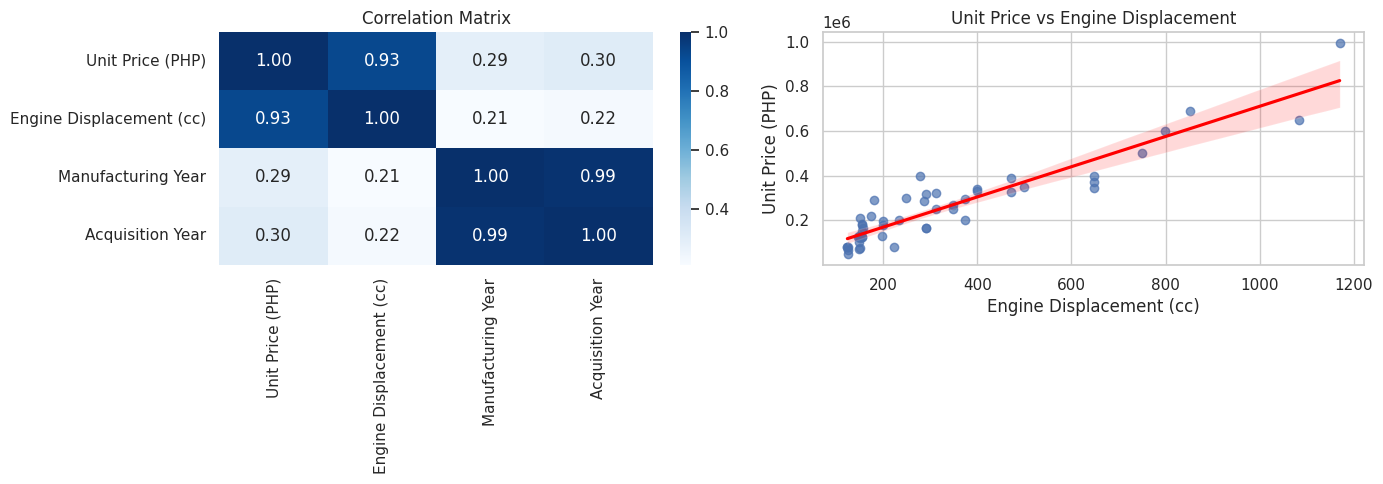

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=axes[0]); axes[0].set_title("Correlation Matrix")
sns.regplot(data=df, x=CC, y=PRICE, ax=axes[1], scatter_kws={"alpha": .7}, line_kws={"color": "red"})
axes[1].set_title("Unit Price vs Engine Displacement")
plt.tight_layout(); plt.show()

In [42]:
# Median price per displacement band
bands = pd.cut(df[CC], [0,150,160,250,400,700,2000], labels=["≤150","151–160","161–250","251–400","401–700",">700"])
band_tbl = df.groupby(bands, observed=True)[PRICE].agg(["count","median"])
display(band_tbl) if "display" in globals() else print(band_tbl)

                          count     median
Engine Displacement (cc)                  
≤150                         12  80,900.00
151–160                       6 158,400.00
161–250                       8 198,500.00
251–400                      13 284,900.00
401–700                       6 359,000.00
>700                          5 650,000.00


### Interpretation – relationships
- **Engine displacement is the strongest driver of price** (Pearson **r ≈ 0.93**): bigger engines carry much higher prices. Median price climbs from about ₱80,900 for bikes up to 150 cc to ₱650,000 for those above 700 cc.
- Manufacturing and acquisition year are almost perfectly correlated (r ≈ 0.99), as expected from the 1-year gap, and each has only a weak positive link to price (r ≈ 0.3).
- Correlation shows association, not cause, and with 50 products these figures are descriptive only.

# **7. OUTLIERS AND EXTREMES**

In [43]:
q1, q3 = df[PRICE].quantile([.25, .75]); upper = q3 + 1.5*(q3 - q1)
print("IQR upper fence:", f"{upper:,.0f}")
print("\nPrice outliers (IQR rule):")
display(df.loc[df[PRICE] > upper, ["Product Name", "Product Type", CC, PRICE]]) if "display" in globals() else print(df.loc[df[PRICE] > upper, ["Product Name", PRICE]])
print("\nTop 5 highest priced:");  print(df.nlargest(5, PRICE)[["Product Name", PRICE]].to_string(index=False))
print("\nTop 5 lowest priced:");   print(df.nsmallest(5, PRICE)[["Product Name", PRICE]].to_string(index=False))
print("\nPrice brackets:")
print(pd.cut(df[PRICE], [0,100000,200000,350000,np.inf], labels=["≤100K","100K–200K","200K–350K",">350K"]).value_counts().sort_index())

IQR upper fence: 635,988

Price outliers (IQR rule):
           Product Name  Unit Price (PHP)
40          BMW R nineT        995,000.00
41     Honda Rebel 1100        650,000.00
48  Moto Guzzi V7 Stone        689,000.00

Top 5 highest priced:
              Product Name  Unit Price (PHP)
               BMW R nineT        995,000.00
       Moto Guzzi V7 Stone        689,000.00
          Honda Rebel 1100        650,000.00
              KTM 790 Duke        599,000.00
Harley-Davidson Street 750        499,000.00

Top 5 lowest priced:
          Product Name  Unit Price (PHP)
        Rusi Flash 125         48,000.00
           Bajaj CT125         67,900.00
  Keeway RKS 150 Sport         68,900.00
         SYM Husky 150         72,900.00
Motorstar Xplorer 250R         78,900.00

Price brackets:
Unit Price (PHP)
≤100K         9
100K–200K    16
200K–350K    16
>350K         9
Name: count, dtype: int64


### Interpretation – outliers
- Three models exceed the IQR upper fence (about ₱636,000): **BMW R nineT (₱995,000)**, **Moto Guzzi V7 Stone (₱689,000)** and **Honda Rebel 1100 (₱650,000)**. These are genuine premium/heritage models, not data errors, so they were kept.
- The lowest-priced items are Rusi Flash 125 (₱48,000), Bajaj CT125 (₱67,900) and Keeway RKS 150 Sport (₱68,900).
- Price brackets are balanced in the middle: 9 models at ₱100K or below, 16 at ₱100K–200K, 16 at ₱200K–350K and 9 above ₱350K.

# **8. SUMMARY OF KEY FINDINGS**
1. The catalogue has **50 products from 23 brands**, with no missing or duplicate records.
2. **Prices are right-skewed**: mean ₱257,872 vs median ₱204,950, with a range of ₱48,000–₱995,000.
3. The typical product is a **single-cylinder (74%), liquid-cooled (68%), 6-speed (60%)** motorcycle; **scooters** are the largest type (24%).
4. **Engine displacement drives price** (r ≈ 0.93); heritage and cruiser types and multi-cylinder engines are the most expensive.
5. The line-up is **recent**: 74% of models were made in 2022–2023, and nearly all were acquired one year after manufacture.
6. Three premium models are statistical price outliers but are valid data.